In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

import sys
sys.path.append('../src') 

from model import TerrainGenerator
from config import LATENT_DIM, TILE_SIZE, CONDITION_WIDTH

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Testing on: {device}")

# Initialize the architecture using TerrainGenerator
generator = TerrainGenerator(LATENT_DIM).to(device)

# Load the weights 
weights_path = '../models/generatorcGAN3.pth'
state_dict = torch.load(weights_path, map_location=device)

generator.load_state_dict(state_dict)
generator.eval()
print("Weights loaded successfully!")

Testing on: cuda
Weights loaded successfully!


Stitched 3x3 terrain shape: (3, 2048, 2048)


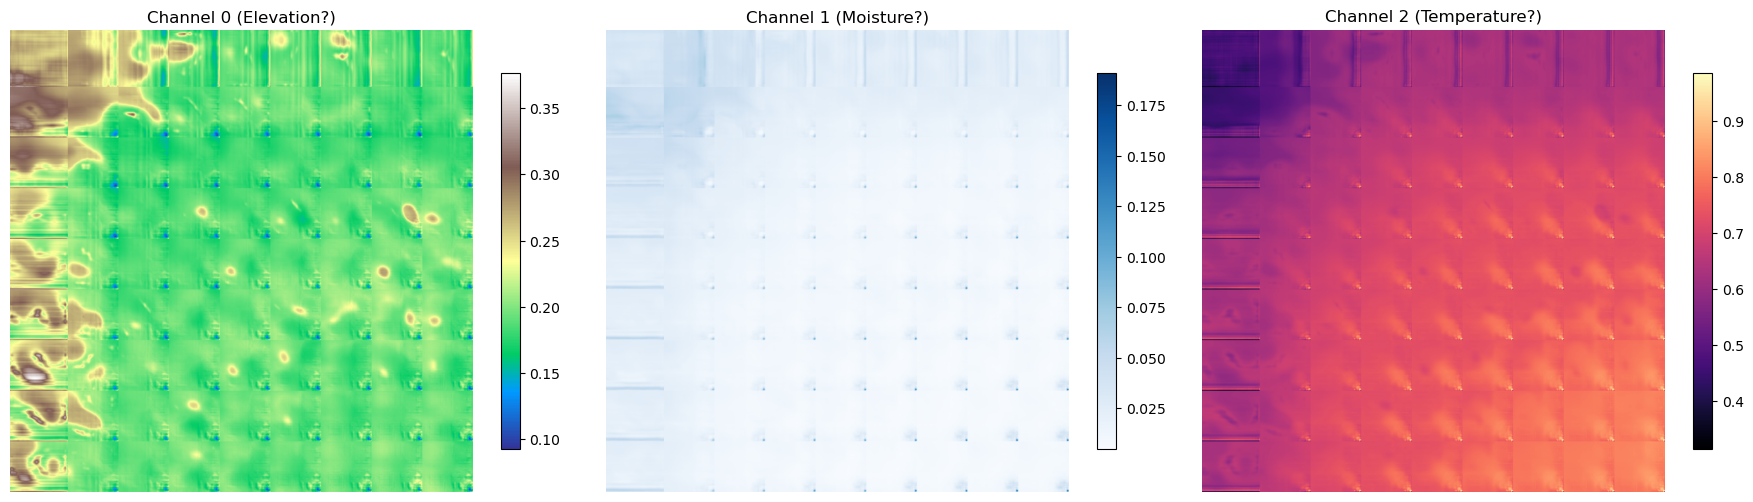

In [59]:
import torch

def generate_terrain_grid(generator, rows, cols, latent_dim, tile_size, condition_width, device, blending=True):
    """
    Generates and stitches a 2D grid of terrain tiles.
    Set blending=False to disable gradient blending and inspect raw seams.
    """
    total_h = tile_size + (rows - 1) * (tile_size - condition_width)
    total_w = tile_size + (cols - 1) * (tile_size - condition_width)
    
    canvas = torch.rand(1, 3, total_h, total_w, device=device)
    
    if blending:
        alpha_y = torch.linspace(0.0, 1.0, condition_width, device=device).view(1, 1, condition_width, 1)
        alpha_x = torch.linspace(0.0, 1.0, condition_width, device=device).view(1, 1, 1, condition_width)

    for r in range(rows):
        for c in range(cols):
            y_start = r * (tile_size - condition_width)
            y_end = y_start + tile_size
            x_start = c * (tile_size - condition_width)
            x_end = x_start + tile_size
            
            mask = torch.zeros(1, 1, tile_size, tile_size, device=device)
            condition = torch.zeros(1, 3, tile_size, tile_size, device=device)
            
            W = torch.ones(1, 1, tile_size, tile_size, device=device)
            
            if r > 0:
                mask[:, :, :condition_width, :] = 1.0
                condition[:, :, :condition_width, :] = canvas[:, :, y_start:y_start+condition_width, x_start:x_end]
                
                if blending:
                    W[:, :, :condition_width, :] = torch.min(W[:, :, :condition_width, :], alpha_y)
                else:
                    W[:, :, :condition_width, :] = 0.0 
                
            if c > 0:
                mask[:, :, :, :condition_width] = 1.0
                condition[:, :, :, :condition_width] = canvas[:, :, y_start:y_end, x_start:x_start+condition_width]
                
                if blending:
                    W[:, :, :, :condition_width] = torch.min(W[:, :, :, :condition_width], alpha_x)
                else:
                    W[:, :, :, :condition_width] = 0.0

            noise = torch.randn(1, latent_dim, 1, 1, device=device)
            with torch.no_grad():
                new_tile = generator(noise, condition, mask)
            
            canvas_patch = canvas[:, :, y_start:y_end, x_start:x_end]
            blended = (1.0 - W) * canvas_patch + W * new_tile
            canvas[:, :, y_start:y_end, x_start:x_end] = blended

    return canvas.squeeze().cpu().numpy()

terrain_map = generate_terrain_grid(
    generator=generator, 
    rows=9, 
    cols=9, 
    latent_dim=LATENT_DIM, 
    tile_size=TILE_SIZE, 
    condition_width=CONDITION_WIDTH, 
    device=device,
    blending=False 
)

print(f"Stitched 3x3 terrain shape: {terrain_map.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(terrain_map[0], cmap='terrain')
axes[0].set_title("Channel 0 (Elevation?)")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(terrain_map[1], cmap='Blues')
axes[1].set_title("Channel 1 (Moisture?)")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(terrain_map[2], cmap='magma')
axes[2].set_title("Channel 2 (Temperature?)")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

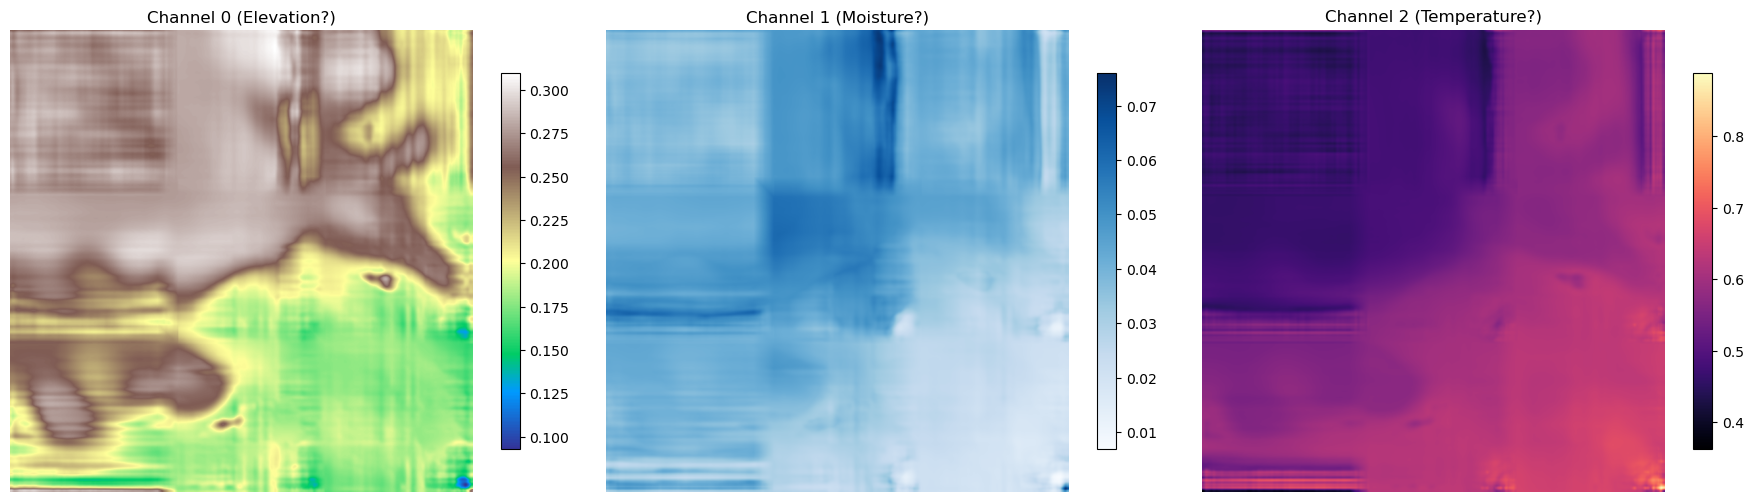

In [23]:
import pyvista as pv
import numpy as np

pv.set_jupyter_backend('trame') 

elevation = terrain_map[0]

x = np.arange(0, elevation.shape[1], 1)
y = np.arange(0, elevation.shape[0], 1)
x, y = np.meshgrid(x, y)

z_exaggeration = 50.0 
z = elevation * z_exaggeration

grid = pv.StructuredGrid(x, y, z)

grid.point_data["Elevation"] = elevation.flatten(order="F")

plotter = pv.Plotter(window_size=[800, 600])

plotter.add_mesh(
    grid, 
    scalars="Elevation",
    cmap="terrain",
    show_edges=False,
    lighting=True
)

plotter.add_axes()
plotter.set_background('white')

plotter.show()

C:\Users\Orzeł\AppData\Local\Temp\ipykernel_17172\2924208182.py:15: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  grid = pv.StructuredGrid(x, y, z)


Widget(value='<iframe src="http://localhost:49837/index.html?ui=P_0x27788442d50_5&reconnect=auto" class="pyvis…